# 06_2 - CNN simple cargando en cada batch

CNN simple con la estrategia antigua: las imagenes se leen desde `.tif` dentro de cada batch mediante una `Sequence`. Sirve como comparacion directa contra RAM y contra arrays `.npy`.


## Librerias y configuracion


In [1]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

RUN_START = time.perf_counter()

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


2026-05-29 09:17:17.012621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780046237.219578      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780046237.284329      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780046237.823725      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780046237.823764      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780046237.823766      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(f'No se encontro xview_ann_train.json. Inputs disponibles: {available_inputs}')

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working')

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition
ANN_JSON: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


## Datos


### Lectura del JSON


In [3]:
with open(ANN_JSON, 'r', encoding='utf-8') as f:
    json_data = json.load(f)

categories = {
    int(k): v['name']
    for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))
}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}
num_classes = len(category_names)

rows = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    rows.append({
        'image_id': json_img['image_id'],
        'filename': json_img['filename'],
        'width': json_img['width'],
        'height': json_img['height'],
        'category': json_ann['category_id'],
        'label': category_to_idx[json_ann['category_id']],
        'bbox': json_ann['bbox'],
        'exists': (DATA_ROOT / json_img['filename']).exists(),
    })

df = pd.DataFrame(rows)
print('Categorias:')
print(categories)
print('Total train:', len(df))
print('Archivos encontrados:', int(df['exists'].sum()))
df.head()


Categorias:
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Total train: 18746
Archivos encontrados: 18746


,image_id,filename,width,height,category,label,bbox,exists
0,0234476c-a017-4c9b-bd2f-872193076cca.tif,xview_train/Building/0234476c-a017-4c9b-bd2f-8...,224,224,Building,8,"[0, 0, 224, 224]",True
1,f2543073-9933-44c4-98e0-15eee2dffe2a.tif,xview_train/Building/f2543073-9933-44c4-98e0-1...,224,224,Building,8,"[0, 0, 224, 224]",True
2,6df5b6a5-82b0-4abb-8deb-7d7154c977bc.tif,xview_train/Building/6df5b6a5-82b0-4abb-8deb-7...,224,224,Building,8,"[0, 0, 224, 224]",True
3,ddbd2636-ce3c-4406-a5cf-92fa557dbd3c.tif,xview_train/Building/ddbd2636-ce3c-4406-a5cf-9...,224,224,Building,8,"[0, 0, 224, 224]",True
4,609064d1-3719-4163-ad36-577dab9805f0.tif,xview_train/Building/609064d1-3719-4163-ad36-5...,224,224,Building,8,"[0, 0, 224, 224]",True


Distribucion por clase:
category
Cargo plane            635
Small car             3324
Bus                   1768
Truck                 2210
Motorboat             1069
Fishing vessel         706
Dump truck            1236
Excavator              789
Building              3594
Helipad                111
Storage tank          1469
Shipping container    1523
Pylon                  312
Name: count, dtype: int64


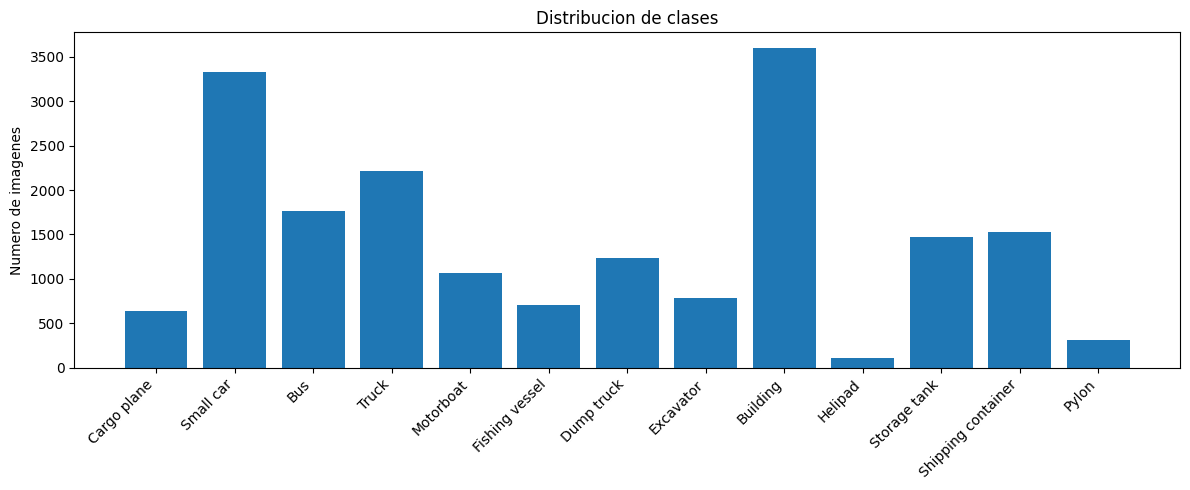

In [4]:
class_counts = df['category'].value_counts().reindex(category_names)
print('Distribucion por clase:')
print(class_counts)

plt.figure(figsize=(12, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Numero de imagenes')
plt.title('Distribucion de clases')
plt.tight_layout()
plt.show()


### Comprobacion de una imagen


In [5]:
def load_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Indice de clase: 8
Bounding box: [0, 0, 224, 224]
Primeros pixeles del array:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


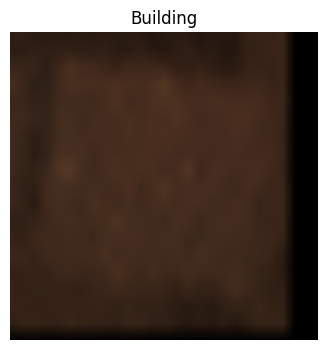

In [6]:
sample_row = df.iloc[0]
sample_img = load_image(sample_row['filename'])

print('Filename:', sample_row['filename'])
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', sample_row['category'])
print('Indice de clase:', sample_row['label'])
print('Bounding box:', sample_row['bbox'])
print('Primeros pixeles del array:')
print(sample_img[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(sample_row['category'])
plt.axis('off')
plt.show()


### Split train/valid


In [7]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=df['label'],
)

print('Train:', len(train_df))
print('Validation:', len(val_df))

split_counts = pd.concat([
    train_df['category'].value_counts().reindex(category_names).rename('train'),
    val_df['category'].value_counts().reindex(category_names).rename('valid'),
], axis=1)
split_counts


Train: 15934
Validation: 2812


,train,valid
category,,
Cargo plane,540,95
Small car,2825,499
Bus,1503,265
Truck,1878,332
Motorboat,909,160
Fishing vessel,600,106
Dump truck,1051,185
Excavator,671,118
Building,3055,539


### Generadores por batch


In [8]:
DATA_LOAD_START = time.perf_counter()

class XViewSequence(tf.keras.utils.Sequence):
    def __init__(self, data, batch_size=32, shuffle=False):
        self.data = data.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.data))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.data.iloc[batch_idx]
        images = np.stack([load_image(filename) for filename in batch['filename']]).astype(np.uint8)
        labels = tf.keras.utils.to_categorical(batch['label'].to_numpy(), num_classes=num_classes).astype(np.float32)
        return images, labels

BATCH_SIZE = 32
train_seq = XViewSequence(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_seq = XViewSequence(val_df, batch_size=BATCH_SIZE, shuffle=False)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START
print('Train batches:', len(train_seq))
print('Valid batches:', len(val_seq))
print(f'Tiempo preparacion generadores: {DATA_LOAD_TIME:.2f} s')


Train batches: 498
Valid batches: 88
Tiempo preparacion generadores: 0.00 s


## Red


### Arquitectura y summary


In [9]:
BATCH_SIZE = 32
EPOCHS = 40

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1.0 / 255.0),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


I0000 00:00:1780046316.506695      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780046316.513013      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,437 (435.30 KB)

 Trainable params: 111,437 (435.30 KB)

 Non-trainable params: 0 (0.00 B)

### Callbacks


In [10]:
MODEL_PATH = WORKDIR / '06_2_cnn_simple_batch.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_PATH), monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/06_2_cnn_simple_batch.keras


### Entrenamiento


In [11]:
TRAIN_START = time.perf_counter()

history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

TRAIN_TIME = time.perf_counter() - TRAIN_START

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)
print(f'Tiempo entrenamiento: {TRAIN_TIME:.2f} s')


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1780046320.767495     129 service.cc:152] XLA service 0x7dba7c046f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780046320.767553     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780046320.767559     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780046321.194184     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/498 ━━━━━━━━━━━━━━━━━━━━ 1:01:08 7s/step - accuracy: 0.1250 - loss: 2.5739

I0000 00:00:1780046326.133668     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.2091 - loss: 2.2747
Epoch 1: val_accuracy improved from None to 0.26885, saving model to /kaggle/working/06_2_cnn_simple_batch.keras

Epoch 1: finished saving model to /kaggle/working/06_2_cnn_simple_batch.keras
498/498 ━━━━━━━━━━━━━━━━━━━━ 179s 346ms/step - accuracy: 0.2313 - loss: 2.1816 - val_accuracy: 0.2688 - val_loss: 2.0542 - learning_rate: 0.0010
Epoch 2/40
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2948 - loss: 2.0265
Epoch 2: val_accuracy improved from 0.26885 to 0.33677, saving model to /kaggle/working/06_2_cnn_simple_batch.keras

Epoch 2: finished saving model to /kaggle/working/06_2_cnn_simple_batch.keras
498/498 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.3157 - loss: 1.9496 - val_accuracy: 0.3368 - val_loss: 1.8841 - learning_rate: 0.0010
Epoch 3/40
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3678 - loss: 1.7995
Epoch 3: val_accuracy improved from 0.33677 to 0.41003, saving model to /

## Resultados


### Graficas de entrenamiento


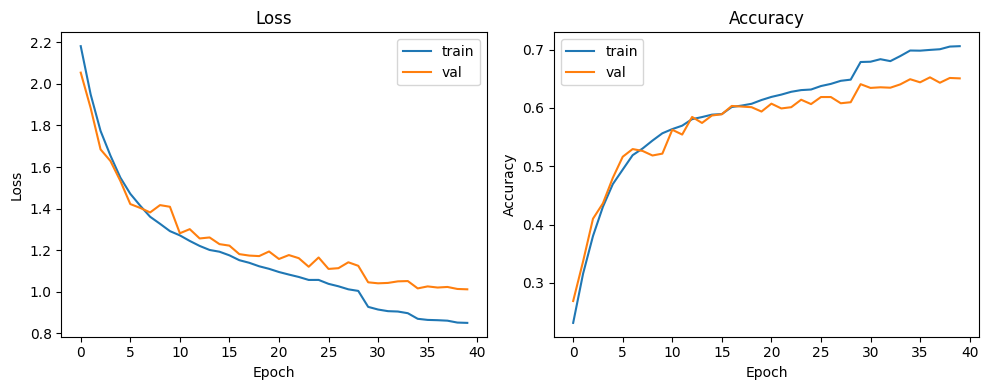

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Matriz de confusion


In [13]:
model.load_weights(MODEL_PATH)
probs = model.predict(val_seq, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = val_df['label'].to_numpy()

cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))


88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step


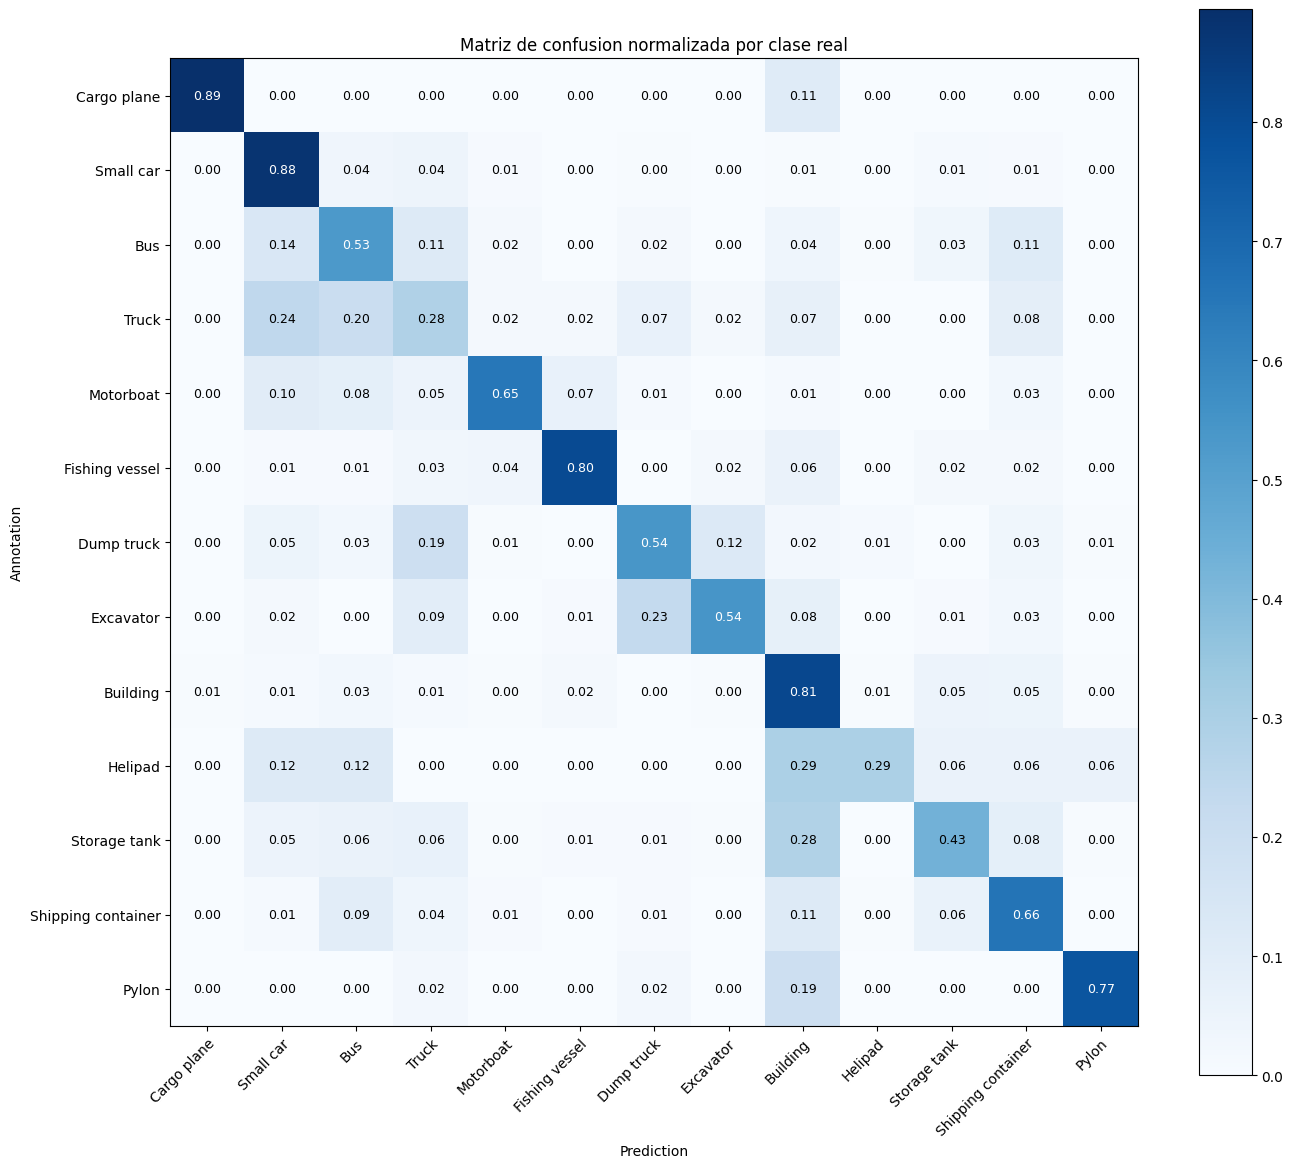

In [14]:
def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='white' if value > threshold else 'black', fontsize=9)

    ax.set_title('Matriz de confusion normalizada por clase real')
    fig.tight_layout()
    plt.show()

draw_confusion_matrix_percent(cm, category_names)


### Metricas por clase


In [15]:
correct = np.diag(cm).astype(float)
total_true = np.sum(cm, axis=1).astype(float)
total_pred = np.sum(cm, axis=0).astype(float)

print('Mean Accuracy: %.3f%%' % (np.sum(correct) / np.sum(total_true) * 100))
print('Mean Recall: %.3f%%' % ((correct / np.maximum(total_true, np.finfo(np.float64).eps)).mean() * 100))
print('Mean Precision: %.3f%%' % ((correct / np.maximum(total_pred, np.finfo(np.float64).eps)).mean() * 100))

for idx, name in enumerate(category_names):
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    recall = tp / np.maximum(tp + fn, np.finfo(np.float64).eps)
    precision = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)
    specificity = tn / np.maximum(tn + fp, np.finfo(np.float64).eps)
    f1_score = 2 * ((precision * recall) / np.maximum(precision + recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (name, recall * 100, precision * 100, specificity * 100, f1_score * 100))


Mean Accuracy: 65.256%
Mean Recall: 62.174%
Mean Precision: 66.014%
> Cargo plane: Recall: 89.474% Precision: 96.591% Specificity: 99.890% Dice: 92.896%
> Small car: Recall: 87.776% Precision: 72.517% Specificity: 92.823% Dice: 79.420%
> Bus: Recall: 52.830% Precision: 47.297% Specificity: 93.875% Dice: 49.911%
> Truck: Recall: 28.313% Precision: 40.343% Specificity: 94.395% Dice: 33.274%
> Motorboat: Recall: 65.000% Precision: 81.250% Specificity: 99.095% Dice: 72.222%
> Fishing vessel: Recall: 80.189% Precision: 75.221% Specificity: 98.965% Dice: 77.626%
> Dump truck: Recall: 54.054% Precision: 60.976% Specificity: 97.564% Dice: 57.307%
> Excavator: Recall: 54.237% Precision: 65.979% Specificity: 98.775% Dice: 59.535%
> Building: Recall: 81.262% Precision: 71.921% Specificity: 92.477% Dice: 76.307%
> Helipad: Recall: 29.412% Precision: 41.667% Specificity: 99.750% Dice: 34.483%
> Storage tank: Recall: 43.182% Precision: 60.897% Specificity: 97.647% Dice: 50.532%
> Shipping container:

## Codabench


In [16]:
CODABENCH_START = time.perf_counter()

def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))

test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_06_2.json'
submission_path = WORKDIR / 'submission_06_2.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_06_2.json - 706530 bytes
/kaggle/working/submission_06_2.zip - 162561 bytes
Tiempo Codabench: 32.89 s


/kaggle/working/submission_06_2.zip

## Tiempo total


In [17]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'TRAIN_TIME' in globals():
    print(f'- Entrenamiento: {TRAIN_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 0.00 s
- Entrenamiento: 2365.34 s
- Codabench: 32.89 s
- Tiempo total Run All: 2475.30 s
- Tiempo total Run All: 41.25 min
